In [27]:
import numpy as np
import pandas as pd 
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve
import matplotlib.pyplot as plt
import joblib

In [28]:
model_df = pd.read_csv('/kaggle/input/datasets/micahluftig/bloomington-model-for-eval/bloomington_model_ready.csv')
x_test_imported = pd.read_csv('/kaggle/input/datasets/micahluftig/recidivism-model-pkl/x_test.csv')
y_test_imported = pd.read_csv('/kaggle/input/datasets/micahluftig/recidivism-model-pkl/y_test.csv')

In [29]:
# ============================================================
# FEATURE MATRIX -- mirrors Austin's build_features()/FEATURE_ORDER exactly
# (from recidivism-model-and-evaluation.ipynb), so this dataset produces
# directly comparable feature vectors for Austin's trained model.
# ============================================================

FEATURE_ORDER = [
    "los_days", "age_at_first_visit",
    "spp_k9", "spp_other", "spp_wildlife",
    "akc_group_hound", "akc_group_mixed_breed", "akc_group_non_sporting",
    "akc_group_sporting", "akc_group_terrier", "akc_group_toy", "akc_group_working",
    "first_reason_medical", "first_reason_other", "first_reason_routine",
]

def build_features(df):
    x = pd.DataFrame(index=df.index)
    x['los_days'] = df['los_days']
    x['age_at_first_visit'] = df['age_in_years']  # Bloomington column name differs from Austin's
    spp = df['spp'].astype(str).str.lower()
    x['spp_k9'] = (spp == 'k9').astype(int)
    x['spp_wildlife'] = (spp == 'wildlife').astype(int)
    x['spp_other'] = ((~spp.isin(['k9', 'fel'])).astype(int) - x['spp_wildlife']).clip(lower=0)
    akc = df['akc_group'].astype(str).str.lower()
    for group in ['hound', 'mixed_breed', 'non_sporting', 'sporting', 'terrier', 'toy', 'working']:
        x[f'akc_group_{group}'] = (akc == group).astype(int)
    reason = df['intake_reason'].astype(str).str.lower()  # Bloomington column name differs from Austin's
    for r in ['medical', 'other', 'routine']:
        x[f'first_reason_{r}'] = (reason == r).astype(int)
    return x[FEATURE_ORDER]

bloomington_features = model_df.dropna(subset=['los_days', 'age_in_years', 'spp', 'akc_group', 'intake_reason']).copy()
x_bloomington = build_features(bloomington_features)
y_bloomington = bloomington_features['was_returned'].astype(int)

print(x_bloomington.shape)
print(x_bloomington.head())
print()
print(f"Recidivism rate in usable rows: {y_bloomington.mean():.2%} ({y_bloomington.sum()} of {len(y_bloomington)})")

(7199, 15)
   los_days  age_at_first_visit  spp_k9  spp_other  spp_wildlife  \
0       2.0              0.0575       0          0             0   
1       2.0              0.0575       0          0             0   
2       2.0              0.0192       0          0             0   
3       2.0              0.0575       0          0             0   
4       7.0              4.5833       0          0             0   

   akc_group_hound  akc_group_mixed_breed  akc_group_non_sporting  \
0                0                      0                       0   
1                0                      0                       0   
2                0                      0                       0   
3                0                      0                       0   
4                0                      0                       0   

   akc_group_sporting  akc_group_terrier  akc_group_toy  akc_group_working  \
0                   0                  0              0                  0   
1        

=== Austin model tested on Bloomington data ===

              precision    recall  f1-score   support

   No Return       0.96      1.00      0.98      6915
    Returned       0.00      0.00      0.00       284

    accuracy                           0.96      7199
   macro avg       0.48      0.50      0.49      7199
weighted avg       0.92      0.96      0.94      7199

ROC AUC: 0.6418
Mean predicted probability: 7.17%
Actual base rate: 3.94%


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


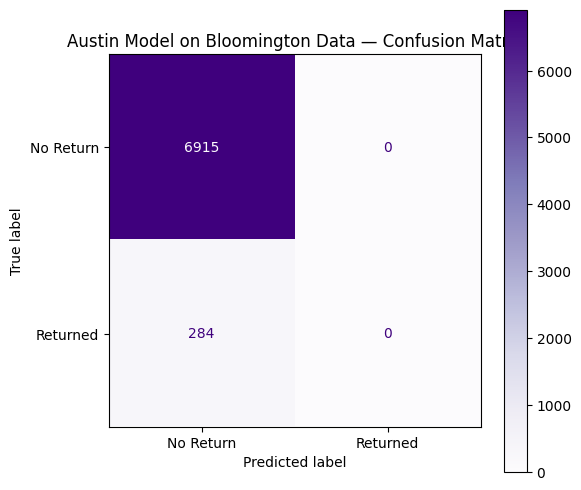

In [30]:
austin_model = joblib.load('/kaggle/input/datasets/micahluftig/recidivism-model-pkl/recidivism_model.pkl')

bloomington_pred = austin_model.predict(x_bloomington)
bloomington_proba = austin_model.predict_proba(x_bloomington)[:, 1]

print("=== Austin model tested on Bloomington data ===\n")
print(classification_report(y_bloomington, bloomington_pred, target_names=['No Return', 'Returned']))
print(f"ROC AUC: {roc_auc_score(y_bloomington, bloomington_proba):.4f}")
print(f"Mean predicted probability: {bloomington_proba.mean():.2%}")
print(f"Actual base rate: {y_bloomington.mean():.2%}")

cm = confusion_matrix(y_bloomington, bloomington_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Return', 'Returned'])
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Purples', ax=ax)
plt.title('Austin Model on Bloomington Data — Confusion Matrix')
plt.savefig('austin_model_on_bloomington_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [31]:
# ============================================================
# BASELINE: Austin's own held-out test-set AUC, for direct comparison
# against Bloomington's 0.6418.
# ============================================================

austin_proba = austin_model.predict_proba(x_test_imported)[:, 1]
austin_auc = roc_auc_score(y_test_imported, austin_proba)

print(f"Austin (own test set) AUC:  {austin_auc:.4f}")
print(f"Bloomington AUC:            0.6418")
print(f"Drop:                       {austin_auc - 0.6418:.4f}")

Austin (own test set) AUC:  0.7116
Bloomington AUC:            0.6418
Drop:                       0.0698


Best threshold for Bloomington: 0.1495
At that threshold -- Precision: 0.1278, Recall: 0.1620, F1: 0.1429

              precision    recall  f1-score   support

   No Return       0.97      0.95      0.96      6915
    Returned       0.13      0.16      0.14       284

    accuracy                           0.92      7199
   macro avg       0.55      0.56      0.55      7199
weighted avg       0.93      0.92      0.93      7199



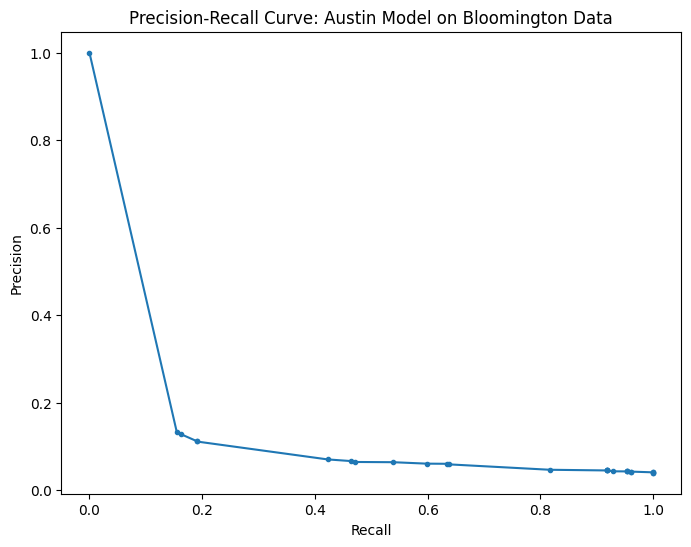

In [32]:
# ============================================================
# Find whether a threshold tuned for Bloomington (rather than Austin's
# default 0.5) makes the model usable here. AUC=0.6418 shows some ranking
# signal transfers; this checks whether that signal is strong enough to
# act on with the right cutoff, or too weak to be practically useful
# regardless of threshold.
# ============================================================

precision, recall, thresholds = precision_recall_curve(y_bloomington, bloomington_proba)

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
best_idx = f1_scores[:-1].argmax()
best_threshold = thresholds[best_idx]

print(f"Best threshold for Bloomington: {best_threshold:.4f}")
print(f"At that threshold -- Precision: {precision[best_idx]:.4f}, Recall: {recall[best_idx]:.4f}, F1: {f1_scores[best_idx]:.4f}")
print()

bloomington_pred_tuned = (bloomington_proba >= best_threshold).astype(int)
print(classification_report(y_bloomington, bloomington_pred_tuned, target_names=['No Return', 'Returned']))

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve: Austin Model on Bloomington Data')
plt.savefig('bloomington_precision_recall_curve.png', dpi=300, bbox_inches='tight')
plt.show()